In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)

device

device(type='mps')

In [4]:
label_map = {
    "airplane": 0,
    "automobile": 1,
    "bird": 2,
    "cat": 3,
    "deer": 4,
    "dog": 5,
    "frog": 6,
    "horse": 7,
    "ship": 8,
    "truck": 9
}

In [5]:
train_labels = pd.read_csv("./cifar-10/trainLabels.csv").to_numpy()[:, 1]

In [30]:
folder = Path('./cifar-10/train')

def pull_data(folder, labels : np.ndarray):
    id_arr = []
    image_arr = []
    label_arr = []

    for file_path in folder.iterdir():
        # Make sure it's a file, not a subfolder
        if file_path.is_file():
            image = np.asarray(Image.open(file_path))
            file_name = file_path.name
            id = int(file_name[:file_name.index(".")])
            id_arr.append(id)
            image_arr.append(image)

    for id in id_arr:
        label = label_map[labels[id - 1]]
        label_arr.append(label)

    return id_arr, image_arr, label_arr

In [31]:
id_arr, image_arr, label_arr = pull_data(folder, train_labels)

In [8]:
data = torch.Tensor(np.asarray(image_arr)).permute(0, 3, 1, 2)
labels = torch.Tensor(np.asarray(label_arr))
labels = labels.to(torch.uint8)

data.shape, labels.shape

(torch.Size([50000, 3, 32, 32]), torch.Size([50000]))

In [9]:
td = TensorDataset(data, labels)
td

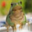

In [10]:
loader = DataLoader(td, batch_size=32)

batch_1 = next(iter(loader))

Image.fromarray(batch_1[0][0].permute(1, 2, 0).numpy().astype(np.uint8))

In [11]:
feature_extractor = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2)
)

In [12]:
test_image = batch_1[0][0].unsqueeze(0)
test_image.shape

torch.Size([1, 3, 32, 32])

In [13]:

features = feature_extractor(test_image.to(next(feature_extractor.parameters()).device))

feature_maps = features[0].detach().cpu()

# for i, feature_map in enumerate(feature_maps):
#     plt.figure()
#     plt.imshow(feature_map.numpy(), cmap="gray")
#     plt.title(f"Feature map {i}")
#     plt.axis("off")
#     plt.show()

In [14]:
model = nn.Sequential(
    feature_extractor,
    nn.Flatten(),
    nn.LazyLinear(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
)

model = model.to(device, dtype=torch.float32)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Keep the per-epoch numbers rather than only printing them. A printed log is
# unusable as data -- it can't be plotted, diffed against another run, or
# checked for the epoch where the curve flattens.
history = {"loss": [], "accuracy": []}

for epoch in range(25):
    running_loss = 0.0
    correct_cnt = 0
    total = 0

    for batch_data, batch_labels in loader:
        batch_data = batch_data.to(device, dtype=torch.float32) / 255.0

        batch_labels = batch_labels.to(device, dtype=torch.long)

        optimizer.zero_grad()

        pred = model(batch_data)

        pred_labels = torch.argmax(pred, dim=1)

        # .item() pulls the count back to a Python int instead of accumulating a
        # chain of on-device tensors across the whole epoch.
        correct_cnt += torch.sum(batch_labels == pred_labels).item()
        total += pred.shape[0]

        loss = criterion(pred, batch_labels)

        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    running_loss /= len(loader) 
    accuracy = correct_cnt / total

    history["loss"].append(running_loss)
    history["accuracy"].append(accuracy)

    print(
        f"Epoch {epoch + 1}: "
        f"loss={running_loss:.4f}, "
        f"accuracy={accuracy:.2%}"
    )

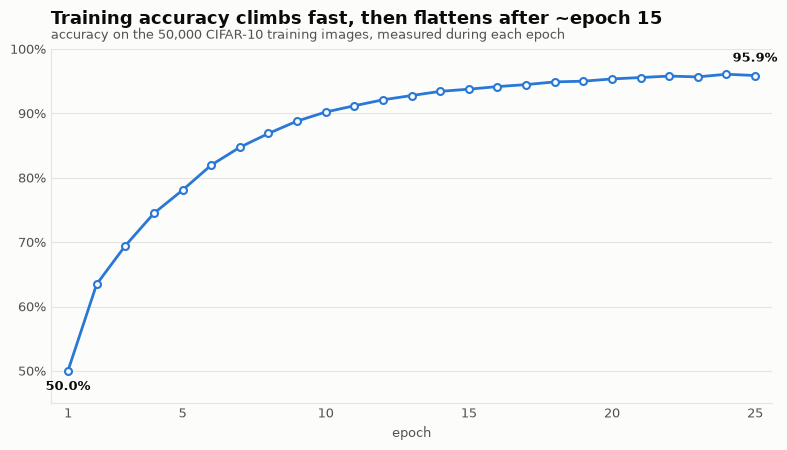

In [3]:
import matplotlib.ticker as mtick

# The cell above now records `history`, but this notebook was trained before it
# did, so fall back to the accuracies it printed. That way the curve renders
# without paying for another 25-epoch run; rerun training and the live numbers
# take over automatically.
LOGGED_ACCURACY = [
    0.5005, 0.6347, 0.6944, 0.7448, 0.7808, 0.8196, 0.8473, 0.8688, 0.8880,
    0.9021, 0.9118, 0.9211, 0.9277, 0.9342, 0.9376, 0.9416, 0.9447, 0.9489,
    0.9500, 0.9535, 0.9557, 0.9579, 0.9567, 0.9608, 0.9588,
]

accuracy_series = history["accuracy"] if "history" in globals() else LOGGED_ACCURACY
epochs = range(1, len(accuracy_series) + 1)

BLUE, SURFACE = "#2a78d6", "#fcfcfb"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e5e4e0"

fig, ax = plt.subplots(figsize=(8, 4.6))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(
    epochs, accuracy_series,
    color=BLUE, linewidth=2,
    marker="o", markersize=5,
    markerfacecolor=SURFACE, markeredgecolor=BLUE, markeredgewidth=1.5,
)

# Label the two endpoints only. A number on all 25 points is noise -- the shape
# of the line already carries everything in between.
for x, y, va in ((1, accuracy_series[0], "top"), (len(accuracy_series), accuracy_series[-1], "bottom")):
    ax.annotate(
        f"{y:.1%}", (x, y),
        textcoords="offset points", xytext=(0, -14 if va == "top" else 10),
        ha="center", fontsize=9, color=INK, fontweight="bold",
    )

# Recessive gridlines behind the data, horizontal only: the reader compares
# accuracy levels, never epoch positions.
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0.45, 1.0)
ax.set_xlim(0.4, len(accuracy_series) + 0.6)
ax.set_xticks([1] + list(range(5, len(accuracy_series) + 1, 5)))
ax.tick_params(colors=MUTED, length=0, labelsize=9)

ax.set_xlabel("epoch", color=MUTED, fontsize=9)
ax.set_title(
    "Training accuracy climbs fast, then flattens after ~epoch 15",
    color=INK, fontsize=13, fontweight="bold", loc="left", pad=18,
)
# Subtitle as a second line under the title: this is accuracy on data the model
# is fitting, so it is a training-progress readout, not a generalization one.
ax.text(
    0, 1.02, "accuracy on the 50,000 CIFAR-10 training images, measured during each epoch",
    transform=ax.transAxes, color=MUTED, fontsize=9.5, va="bottom",
)

fig.tight_layout()
plt.show()

In [16]:
model.eval()

for parameter in model.parameters():
    parameter.requires_grad_(False)

In [17]:
# Target the PRE-ReLU output of conv2, not the post-ReLU one.
#
# model[0] is feature_extractor: [Conv1, ReLU, Conv2, ReLU, MaxPool]
#   [:3] -> Conv1, ReLU, Conv2         (raw conv2 response)
#   [:4] -> ...plus ReLU               (what the previous version used)
#
# Post-ReLU is a trap: a channel whose response to the starting noise is
# negative everywhere outputs exactly 0 everywhere, so its gradient is 0
# everywhere and the image can never move. Pre-ReLU always has gradient, and it
# also lets the optimizer see what the filter *dislikes*, which sharpens the
# pattern it converges on.
target_layer = model[0][:3]

# Receptive field: 3x3 stacked on 3x3 means one conv2 unit sees a 5x5 pixel
# patch. The honest answer to "what is this filter looking for" is therefore a
# 5x5 texture -- on a 32x32 canvas expect that texture tiled, not an object.
target_layer

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [18]:
import math
import torch.nn.functional as F

IMG_SIZE = 32

# ---------------------------------------------------------------------------
# 1. Color decorrelation, measured from CIFAR-10 itself.
#
# R, G and B are strongly correlated in natural images. Gradient descent in raw
# RGB happily moves along directions the data never contains, which is where the
# neon rainbow speckle in naive feature visualizations comes from. Optimizing in
# a whitened basis makes every direction equally plausible as an image.
# ---------------------------------------------------------------------------
_pixels = (data[:5000] / 255.0).permute(1, 0, 2, 3).reshape(3, -1)
_eigvals, _eigvecs = torch.linalg.eigh(torch.cov(_pixels))

color_basis = _eigvecs @ torch.diag(_eigvals.clamp(min=0).sqrt())
color_basis = (color_basis / color_basis.norm(dim=1).max()).to(device)


def decorrelate_color(x):
    """[B, 3, H, W] in the whitened basis -> correlated RGB."""
    return torch.einsum("bchw,dc->bdhw", x, color_basis)


# ---------------------------------------------------------------------------
# 2. Fourier (1/f) parameterization.
#
# With raw pixels as the parameters, neighbouring pixels are independent, so the
# optimizer can dump gradient into high-frequency noise that no real image has.
# Parameterizing by the frequency spectrum and scaling it by 1/f (the spectrum
# of natural images) makes low frequencies cheap to change and high frequencies
# expensive -- a smoothness prior baked into the parameterization instead of
# bolted on as a blur or a TV penalty.
# ---------------------------------------------------------------------------
_fy = torch.fft.fftfreq(IMG_SIZE)[:, None]
_fx = torch.fft.rfftfreq(IMG_SIZE)[None, :]
_freqs = (_fx ** 2 + _fy ** 2).sqrt()

freq_scale = (1.0 / _freqs.clamp(min=1.0 / IMG_SIZE)).to(device) * IMG_SIZE


def make_spectrum(batch, sd=0.05):
    """The trainable parameter is the image's spectrum, not its pixels."""
    return (
        torch.randn(batch, 3, IMG_SIZE, IMG_SIZE // 2 + 1, 2, device=device) * sd
    ).requires_grad_(True)


def spectrum_to_image(spectrum):
    """spectrum -> whitened image -> RGB -> [0, 1].

    sigmoid replaces the old in-place clamp_(0, 1). Clamping zeroes the gradient
    for every pixel sitting on a boundary and silently desynchronizes Adam's
    momentum from the parameter it is tracking; a squashing function keeps the
    image in range while staying differentiable everywhere.
    """
    scaled = torch.view_as_complex(spectrum.contiguous()) * freq_scale
    image = torch.fft.irfft2(scaled, s=(IMG_SIZE, IMG_SIZE)) / 4.0
    return torch.sigmoid(decorrelate_color(image))


# ---------------------------------------------------------------------------
# 3. Transformation robustness.
#
# A single un-augmented image can win by exploiting one exact pixel alignment --
# the same loophole adversarial examples use, and the main reason the old result
# looked like structured static. Requiring the image to keep the channel excited
# under random shift / scale / rotation throws those solutions away and leaves
# only what the filter genuinely responds to.
# ---------------------------------------------------------------------------
def random_transform(
    image, max_roll=4, max_shift=0.12, scale_range=(0.9, 1.1), max_deg=8.0
):
    b = image.shape[0]

    # Whole-batch circular jitter. Cheap, and a conv is translation-equivariant
    # so wrapping around the edge costs nothing.
    roll = torch.randint(-max_roll, max_roll + 1, (2,))
    image = torch.roll(image, shifts=(int(roll[0]), int(roll[1])), dims=(2, 3))

    # Per-sample rotation, scale and sub-pixel shift through one affine grid.
    angle = (torch.rand(b, device=image.device) * 2 - 1) * math.radians(max_deg)
    scale = torch.empty(b, device=image.device).uniform_(*scale_range)
    cos, sin = torch.cos(angle) / scale, torch.sin(angle) / scale

    theta = torch.zeros(b, 2, 3, device=image.device)
    theta[:, 0, 0], theta[:, 0, 1] = cos, -sin
    theta[:, 1, 0], theta[:, 1, 1] = sin, cos
    theta[:, :, 2] = (torch.rand(b, 2, device=image.device) * 2 - 1) * max_shift

    grid = F.affine_grid(theta, image.shape, align_corners=False)
    return F.grid_sample(
        image, grid, mode="bilinear", padding_mode="reflection", align_corners=False
    )

step    0: mean activation = -0.7515
step  100: mean activation = -0.3650
step  200: mean activation = -0.2573
step  300: mean activation = -0.2438
step  400: mean activation = -0.2009
step  500: mean activation = -0.2208


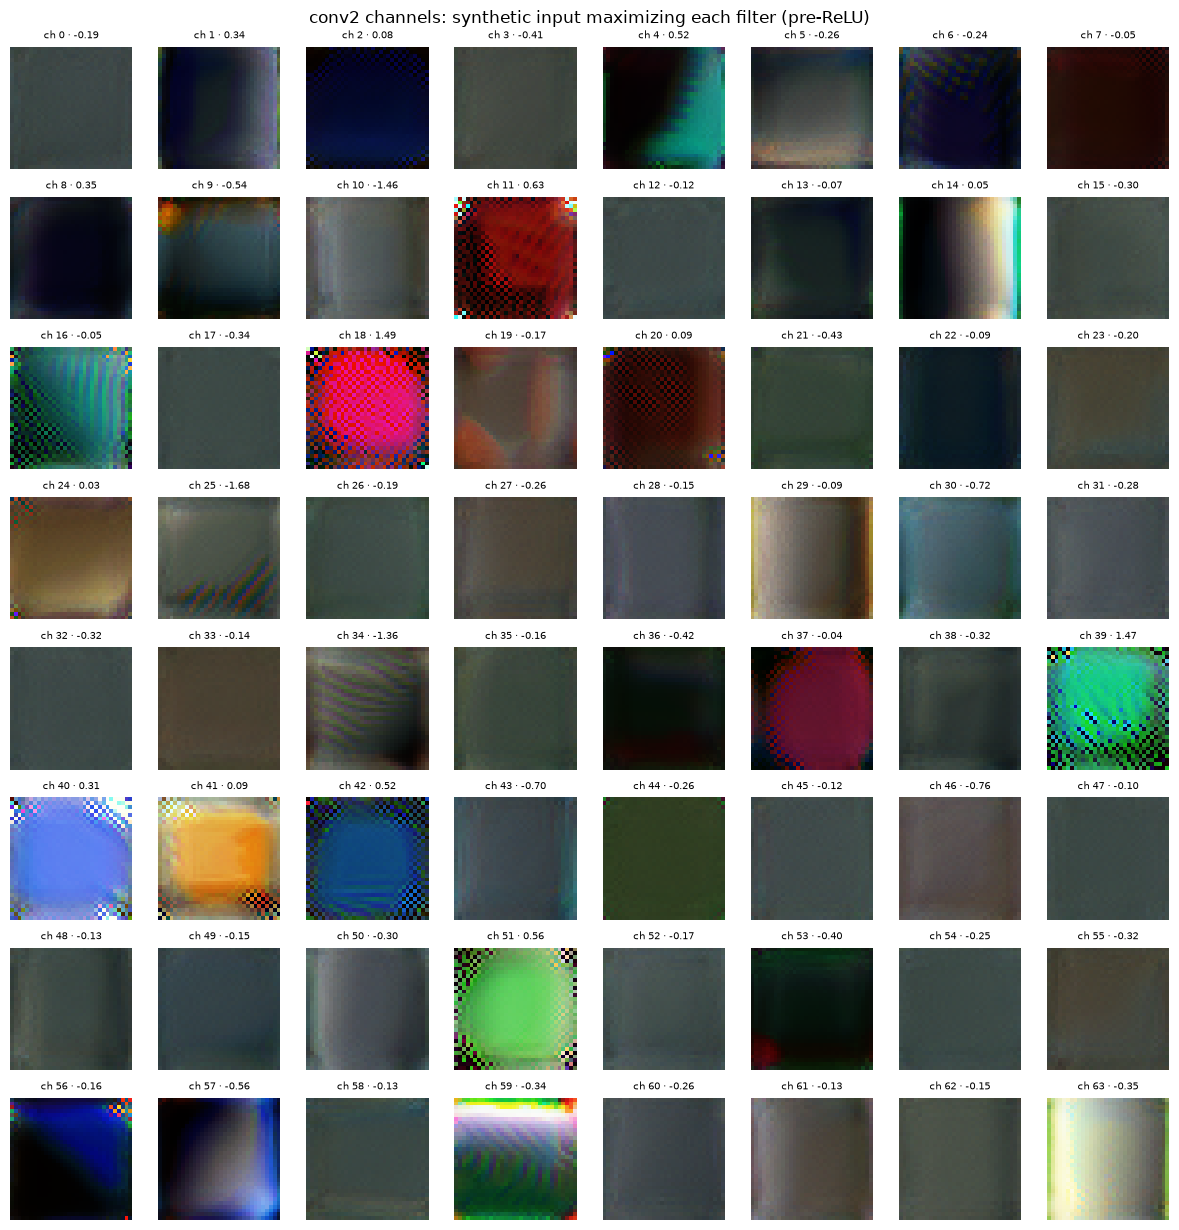

In [19]:
# Optimize all 64 conv2 channels at once instead of one target_channel at a
# time. Batch element i is the image built for channel i; a conv never mixes
# information across the batch dimension, so these 64 optimizations are exactly
# as independent as 64 separate runs, for the price of one.
n_channels = target_layer[-1].out_channels
channel_idx = torch.arange(n_channels, device=device)

# padding=1 on both convs means activations within 2 px of the edge saw zero
# padding rather than image. Drop that rim so the objective is only fed units
# whose 5x5 receptive field is real content.
BORDER = 3
STEPS = 512

spectrum = make_spectrum(n_channels)
optimizer = torch.optim.Adam([spectrum], lr=0.05)

for step in range(STEPS):
    optimizer.zero_grad()

    images = spectrum_to_image(spectrum)
    acts = target_layer(random_transform(images))  # [64, 64, 32, 32]

    # acts[i, i] -> the response of channel i on the image built for channel i.
    picked = acts[channel_idx, channel_idx][:, BORDER:-BORDER, BORDER:-BORDER]
    objective = picked.mean(dim=(1, 2))

    # Optimizers minimize; sum is fine because the terms don't interact.
    (-objective.sum()).backward()
    optimizer.step()

    if step % 100 == 0:
        print(f"step {step:>4}: mean activation = {objective.mean().item():.4f}")

# Score the final images untransformed, so the number reported is the activation
# of the picture actually being displayed.
with torch.no_grad():
    final_images = spectrum_to_image(spectrum)
    final_score = (
        target_layer(final_images)[channel_idx, channel_idx][
            :, BORDER:-BORDER, BORDER:-BORDER
        ]
        .mean(dim=(1, 2))
        .cpu()
    )
final_images = final_images.cpu()

fig, axes = plt.subplots(8, 8, figsize=(12, 12.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(final_images[i].permute(1, 2, 0).numpy())
    ax.set_title(f"ch {i} · {final_score[i]:.2f}", fontsize=7)
    ax.axis("off")

fig.suptitle("conv2 channels: synthetic input maximizing each filter (pre-ReLU)")
fig.tight_layout()
plt.show()

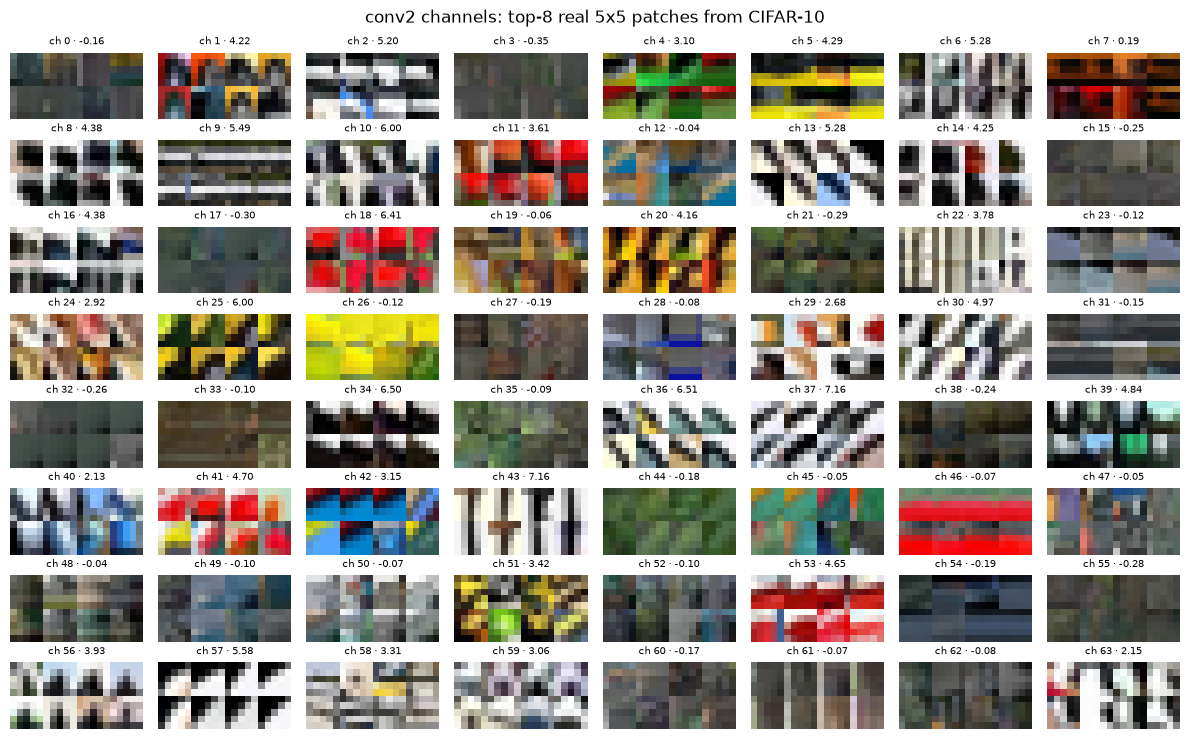

In [20]:
# Cross-check: synthetic images can lie. Optimization finds *an* input the
# channel loves, not necessarily one resembling anything in the data. So also
# pull the real 5x5 patches from CIFAR-10 that actually drive each channel
# hardest -- the two views should tell the same story, and where they disagree
# the dataset patches are the ground truth.
N_IMAGES = 8192
TOP_K = 8
RF = 5              # conv2 receptive field
HALF = RF // 2

top_vals = torch.full((n_channels, TOP_K), -float("inf"))
top_idx = torch.zeros((n_channels, TOP_K, 3), dtype=torch.long)  # (image, row, col)

with torch.no_grad():
    for start in range(0, N_IMAGES, 512):
        batch = (data[start:start + 512] / 255.0).to(device)

        # Trim the rim again: only units whose 5x5 window lies fully in-image.
        acts = target_layer(batch)[:, :, HALF:-HALF, HALF:-HALF]
        b, c, h, w = acts.shape

        vals, pos = acts.permute(1, 0, 2, 3).reshape(c, -1).topk(TOP_K, dim=1)
        vals, pos = vals.cpu(), pos.cpu()

        img = start + pos // (h * w)
        rem = pos % (h * w)
        row, col = rem // w + HALF, rem % w + HALF

        # Merge this batch's top-K into the running top-K.
        cand_vals = torch.cat([top_vals, vals], dim=1)
        cand_idx = torch.cat([top_idx, torch.stack([img, row, col], dim=-1)], dim=1)
        keep = cand_vals.topk(TOP_K, dim=1).indices
        top_vals = cand_vals.gather(1, keep)
        top_idx = cand_idx.gather(1, keep.unsqueeze(-1).expand(-1, -1, 3))

# Pad by HALF so a patch centred on (row, col) is just a slice.
padded = F.pad(data[:N_IMAGES] / 255.0, (HALF,) * 4)

montages = []
for c in range(n_channels):
    patches = torch.stack(
        [padded[i, :, r:r + RF, cc:cc + RF] for i, r, cc in top_idx[c].tolist()]
    )
    # [8, 3, 5, 5] -> a 2x4 tile of patches
    montages.append(
        patches.reshape(2, 4, 3, RF, RF)
        .permute(2, 0, 3, 1, 4)
        .reshape(3, 2 * RF, 4 * RF)
    )
montages = torch.stack(montages)

fig, axes = plt.subplots(8, 8, figsize=(12, 7.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(montages[i].permute(1, 2, 0).numpy(), interpolation="nearest")
    ax.set_title(f"ch {i} · {top_vals[i, 0]:.2f}", fontsize=7)
    ax.axis("off")

fig.suptitle(f"conv2 channels: top-{TOP_K} real {RF}x{RF} patches from CIFAR-10")
fig.tight_layout()
plt.show()

In [ ]:
# The Kaggle test folder ships without labels, and only 10,000 of its 300,000
# images are real CIFAR-10 -- the other 290,000 are junk images added to make
# hand-labeling infeasible. recover_test_labels.py finds the real ones by
# matching every test image against the official CIFAR-10 test batch from
# cs.toronto.edu and writes out their ids and true labels, so what loads here is
# the genuine held-out test set: 10,000 images the model has never seen.
test_folder = Path('./cifar-10/test')

test_labels_df = pd.read_csv("./cifar-10/testLabels.csv")

test_id_arr = test_labels_df["id"].to_numpy()
test_label_arr = np.array([label_map[name] for name in test_labels_df["label"]])

# Indexed by id rather than folder order -- iterdir() would walk all 300,000.
test_image_arr = np.stack([
    np.asarray(Image.open(test_folder / f"{id}.png")) for id in test_id_arr
])

test_image_arr.shape, test_label_arr.shape

In [ ]:
test_data = torch.Tensor(test_image_arr).permute(0, 3, 1, 2)
test_labels = torch.Tensor(test_label_arr).to(torch.uint8)

# Bigger batches than training: no gradients to hold, so this is a pure
# throughput knob.
test_loader = DataLoader(TensorDataset(test_data, test_labels), batch_size=256)

test_data.shape, test_labels.shape

In [ ]:
# eval() matters here: the Dropout layer must stop dropping, otherwise every
# prediction is made by a randomly crippled network and the accuracy comes out
# low for a reason that has nothing to do with generalization.
model.eval()

pred_chunks = []
conf_chunks = []

with torch.no_grad():
    for batch_data, batch_labels in test_loader:
        # Same preprocessing as training -- /255.0. A model fed 0-255 at test
        # time after being trained on 0-1 predicts noise.
        batch_data = batch_data.to(device, dtype=torch.float32) / 255.0

        logits = model(batch_data)
        probs = torch.softmax(logits, dim=1)

        conf, pred = probs.max(dim=1)
        pred_chunks.append(pred.cpu())
        conf_chunks.append(conf.cpu())

test_preds = torch.cat(pred_chunks).to(torch.uint8)
test_conf = torch.cat(conf_chunks)

hits = test_preds == test_labels
test_accuracy = hits.float().mean().item()

print(f"test accuracy: {test_accuracy:.2%} ({hits.sum().item()}/{len(test_labels)})")
print()

# Per class, because a single number hides which classes the model actually
# fails on -- CIFAR-10 models typically look fine on ships and awful on cats.
for name, c in label_map.items():
    in_class = test_labels == c
    print(
        f"{name:>10}: {hits[in_class].float().mean():.2%} "
        f"({hits[in_class].sum().item()}/{in_class.sum().item()})"
    )

In [ ]:
class_names = list(label_map)

N_SHOW = 8
# Seeded so the "random" rows are the same picture every rerun -- a figure that
# reshuffles on each execution can't be compared against the last run.
gen = torch.Generator().manual_seed(0)


def sample(idx, n=N_SHOW):
    return idx[torch.randperm(len(idx), generator=gen)[:n]]


correct_idx = hits.nonzero().squeeze(1)
wrong_idx = (~hits).nonzero().squeeze(1)

# Third row is the interesting one: mistakes ranked by the model's own
# confidence. Random errors are mostly genuinely ambiguous 32x32 blobs, while
# confidently wrong predictions show what the model has actually learned to
# confuse -- and a 95%-sure wrong answer is the failure that would hurt in
# production, since nothing downstream can flag it.
confident_wrong = wrong_idx[test_conf[wrong_idx].argsort(descending=True)][:N_SHOW]

rows = [
    ("correct", sample(correct_idx), "green"),
    ("incorrect", sample(wrong_idx), "red"),
    ("incorrect, highest confidence", confident_wrong, "red"),
]

fig, axes = plt.subplots(len(rows), N_SHOW, figsize=(1.6 * N_SHOW, 2.3 * len(rows)))

for (title, idx, color), ax_row in zip(rows, axes):
    for ax, i in zip(ax_row, idx.tolist()):
        ax.imshow(test_image_arr[i], interpolation="nearest")
        true_name = class_names[test_labels[i]]
        pred_name = class_names[test_preds[i]]

        label = (
            f"{true_name}"
            if test_preds[i] == test_labels[i]
            else f"{true_name} → {pred_name}"
        )
        ax.set_title(f"{label}\n{test_conf[i]:.0%} confident", fontsize=8, color=color)
        ax.axis("off")

    # Row caption on the left, since a shared title per row is clearer than
    # repeating "correct" eight times.
    ax_row[0].text(
        -0.15, 0.5, title, transform=ax_row[0].transAxes,
        rotation=90, va="center", ha="right", fontsize=9,
    )

fig.suptitle(
    f"CIFAR-10 test set predictions — {test_accuracy:.2%} accuracy "
    f"over {len(test_labels):,} held-out images"
)
fig.tight_layout()
plt.show()